In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual geral para os gráficos ficarem profissionais
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})
cores_equipa = {'Diogo': '#1f77b4', 'Hugo': '#ff7f0e'} # Azul para Backend, Laranja para Frontend

In [18]:
# 1. Carregar os dados
df = pd.read_csv('./issues.csv')

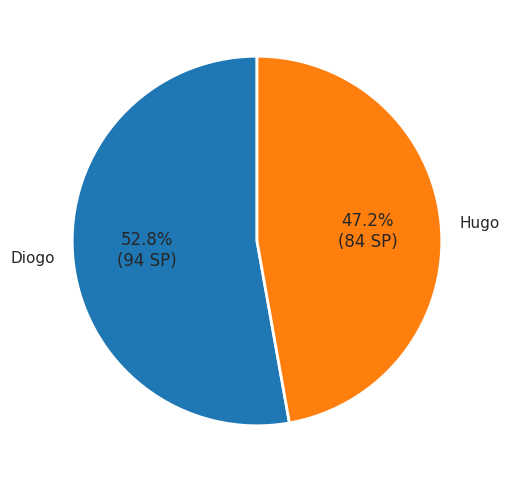

In [19]:
# ---------------------------------------------------------
# GRÁFICO 1: Distribuição Total de ESFORÇO (Story Points)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
# Agrupamos e somamos os Story Points
esforco_total = df.groupby('Assignee')['StoryPoints'].sum()

# Calculamos o total geral para poder descobrir o valor absoluto
total_sp = esforco_total.sum()

# Função auxiliar para formatar a etiqueta (Percentagem + Valor Absoluto)
def formatar_etiqueta(pct):
    valor_absoluto = int(round(pct * total_sp / 100.0))
    return f'{pct:.1f}%\n({valor_absoluto} SP)'

plt.pie(esforco_total, labels=esforco_total.index, autopct=formatar_etiqueta, 
        startangle=90, colors=[cores_equipa[val] for val in esforco_total.index],
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
        
# plt.title('Distribuição de Esforço no Projeto (Story Points)', fontsize=14, fontweight='bold')
plt.show()

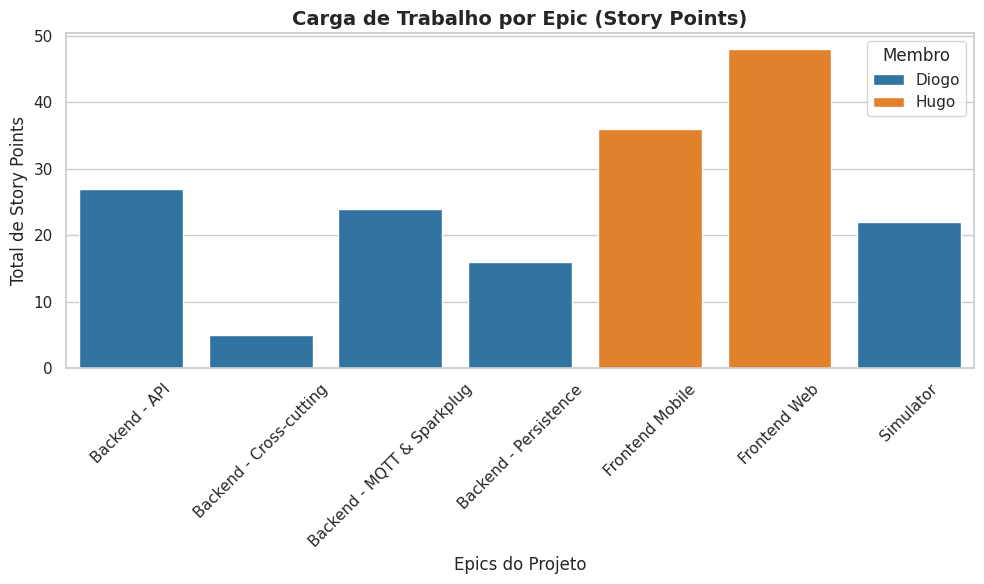

In [20]:
# ---------------------------------------------------------
# GRÁFICO 2: Carga de Trabalho por Epic em Story Points
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
epic_sp = df.groupby(['Epic', 'Assignee'])['StoryPoints'].sum().reset_index()

sns.barplot(data=epic_sp, x='Epic', y='StoryPoints', hue='Assignee', palette=cores_equipa)
plt.title('Carga de Trabalho por Epic (Story Points)', fontsize=14, fontweight='bold')
plt.xlabel('Epics do Projeto')
plt.ylabel('Total de Story Points')
plt.xticks(rotation=45)
plt.legend(title='Membro')
plt.tight_layout()
plt.show()

In [21]:
print(f"Total de Story Points do Projeto: {esforco_total.sum()}")
print("Distribuição:\n", esforco_total)

Total de Story Points do Projeto: 178
Distribuição:
 Assignee
Diogo    94
Hugo     84
Name: StoryPoints, dtype: int64


In [22]:
# ---------------------------------------------------------
# TABELA RESUMO: Impressão dos dados estatísticos
# ---------------------------------------------------------
print("=== RESUMO ESTATÍSTICO ===")
print(pd.crosstab(df['Assignee'], df['Epic'], margins=True, margins_name="Total"))

=== RESUMO ESTATÍSTICO ===
Epic      Backend - API  Backend - Cross-cutting  Backend - MQTT & Sparkplug  \
Assignee                                                                       
Diogo                 7                        2                           6   
Hugo                  0                        0                           0   
Total                 7                        2                           6   

Epic      Backend - Persistence  Frontend Mobile  Frontend Web  Simulator  \
Assignee                                                                    
Diogo                         4                0             0          7   
Hugo                          0                9            13          0   
Total                         4                9            13          7   

Epic      Total  
Assignee         
Diogo        26  
Hugo         22  
Total        48  
